<a href="https://colab.research.google.com/github/shafiq73/2024/blob/main/Y_Profiling_into_codes_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1 dataset load

In [ ]:
import pandas as pd

# Step 1: Load the dataset
df = pd.read_csv("google_play_store_updated.csv")
import pandas as pd

# Step 2: Total rows
Total columns
Missing values count
Duplicate rows
Memory usage

In [ ]:
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size_in_bytes', 'Installs',
       'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated',
       'Current Ver', 'Android Ver', 'Installs_category', 'Size_in_Mb'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
App,0
Category,0
Rating,0
Reviews,0
Size_in_bytes,0
Installs,0
Type,0
Price,0
Content Rating,0
Genres,0


In [ ]:
total_rows = df.shape[0]
total_columns = df.shape[1]
missing_values = df.isnull().sum().sum()

In [ ]:
duplicate_rows = df.duplicated().sum()

In [ ]:
memory_usage = df.memory_usage(deep=True).sum() / (1024 ** 2)

In [ ]:
print("Total Rows:", total_rows)
print("Total Columns:", total_columns)
print("Total Missing Values:", missing_values)
print("Duplicate Rows:", duplicate_rows)
print(f"Memory Usage: {memory_usage:.2f} MB")

Total Rows: 10346
Total Columns: 15
Total Missing Values: 0
Duplicate Rows: 0
Memory Usage: 5.79 MB


# Step 3: Column-wise analysis
Numeric columns
Mean
Median
Min / Max
Standard deviation
Histogram
Outliers detection

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10346 entries, 0 to 10345
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   App                10346 non-null  object 
 1   Category           10346 non-null  object 
 2   Rating             10346 non-null  float64
 3   Reviews            10346 non-null  float64
 4   Size_in_bytes      10346 non-null  float64
 5   Installs           10346 non-null  float64
 6   Type               10346 non-null  object 
 7   Price              10346 non-null  float64
 8   Content Rating     10346 non-null  object 
 9   Genres             10346 non-null  object 
 10  Last Updated       10346 non-null  object 
 11  Current Ver        10346 non-null  object 
 12  Android Ver        10346 non-null  object 
 13  Installs_category  10346 non-null  object 
 14  Size_in_Mb         10346 non-null  float64
dtypes: float64(6), object(9)
memory usage: 1.2+ MB


In [ ]:
df.describe()

,Rating,Reviews,Size_in_bytes,Installs,Price,Size_in_Mb
count,10346.000000,1.034600e+04,1.034600e+04,1.034600e+04,10346.000000,10346.000000
mean,3.596965,4.063338e+05,1.904812e+07,1.417266e+07,1.031561,18.165701
std,1.536360,2.698179e+06,2.322157e+07,8.028090e+07,16.287252,22.145816
min,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,3.700000,3.200000e+01,2.831155e+06,1.000000e+03,0.000000,2.700000
50%,4.200000,1.688500e+03,9.542042e+06,1.000000e+05,0.000000,9.100000
75%,4.500000,4.659825e+04,2.726298e+07,1.000000e+06,0.000000,26.000000
max,5.000000,7.815831e+07,1.048576e+08,1.000000e+09,400.000000,100.000000


# numeric column

In [ ]:
numeric_cols = [
    'Rating',
    'Reviews',
    'Size_in_bytes',
    'Installs',
    'Price',
    'Size_in_Mb'
]

df[numeric_cols].mean()


,0
Rating,3.596965e+00
Reviews,4.063338e+05
Size_in_bytes,1.904812e+07
Installs,1.417266e+07
Price,1.031561e+00
Size_in_Mb,1.816570e+01


# Mean

In [ ]:
mean_df = df[numeric_cols].mean().reset_index()
mean_df.columns = ['Column', 'Mean']
mean_df



,Column,Mean
0,Rating,3.596965e+00
1,Reviews,4.063338e+05
2,Size_in_bytes,1.904812e+07
3,Installs,1.417266e+07
4,Price,1.031561e+00
5,Size_in_Mb,1.816570e+01


In [ ]:
df[numeric_cols].mean().round(2)

,0
Rating,3.60
Reviews,406333.77
Size_in_bytes,19048118.22
Installs,14172659.72
Price,1.03
Size_in_Mb,18.17


# Median

In [ ]:
numeric_cols = ['Rating', 'Reviews', 'Size_in_bytes', 'Installs', 'Price', 'Size_in_Mb']

# Median values
median_df = df[numeric_cols].median().reset_index()
median_df.columns = ['Column', 'Median']
median_df


,Column,Median
0,Rating,4.2
1,Reviews,1688.5
2,Size_in_bytes,9542041.6
3,Installs,100000.0
4,Price,0.0
5,Size_in_Mb,9.1


In [ ]:
median_df = df[numeric_cols].median().reset_index()
median_df.columns = ['Column', 'median']
median_df


,Column,median
0,Rating,4.2
1,Reviews,1688.5
2,Size_in_bytes,9542041.6
3,Installs,100000.0
4,Price,0.0
5,Size_in_Mb,9.1


In [ ]:
df[numeric_cols].median().round(2)


,0
Rating,4.2
Reviews,1688.5
Size_in_bytes,9542041.6
Installs,100000.0
Price,0.0
Size_in_Mb,9.1


# Min

In [ ]:
# Minimum values
min_df = df[numeric_cols].min().reset_index()
min_df.columns = ['Column', 'Min']
min_df


,Column,Min
0,Rating,0.0
1,Reviews,0.0
2,Size_in_bytes,0.0
3,Installs,0.0
4,Price,0.0
5,Size_in_Mb,0.0


# Max

In [ ]:
# Maximum values
max_df = df[numeric_cols].max().reset_index()
max_df.columns = ['Column', 'Max']
max_df


,Column,Max
0,Rating,5.000000e+00
1,Reviews,7.815831e+07
2,Size_in_bytes,1.048576e+08
3,Installs,1.000000e+09
4,Price,4.000000e+02
5,Size_in_Mb,1.000000e+02


# Step 4: Simple Standard Deviation (all numeric columns)

In [ ]:
numeric_cols = ['Rating', 'Reviews', 'Size_in_bytes', 'Installs', 'Price', 'Size_in_Mb']

# Standard Deviation
std_df = df[numeric_cols].std().reset_index()
std_df.columns = ['Column', 'Std_Dev']
std_df


,Column,Std_Dev
0,Rating,1.536360e+00
1,Reviews,2.698179e+06
2,Size_in_bytes,2.322157e+07
3,Installs,8.028090e+07
4,Price,1.628725e+01
5,Size_in_Mb,2.214582e+01


In [ ]:
df[numeric_cols].std().round(2)

,0
Rating,1.54
Reviews,2698179.07
Size_in_bytes,23221570.76
Installs,80280899.86
Price,16.29
Size_in_Mb,22.15


# Combined Summary (Median, Min, Max, Std Dev All in one code)

In [ ]:
summary_df = pd.DataFrame({
    'Column': numeric_cols,
    'Median': df[numeric_cols].median().values,
    'Min': df[numeric_cols].min().values,
    'Max': df[numeric_cols].max().values,
    'Std_Dev': df[numeric_cols].std().values.round(2)
})

summary_df

,Column,Median,Min,Max,Std_Dev
0,Rating,4.2,0.0,5.000000e+00,1.54
1,Reviews,1688.5,0.0,7.815831e+07,2698179.07
2,Size_in_bytes,9542041.6,0.0,1.048576e+08,23221570.76
3,Installs,100000.0,0.0,1.000000e+09,80280899.86
4,Price,0.0,0.0,4.000000e+02,16.29
5,Size_in_Mb,9.1,0.0,1.000000e+02,22.15


# Step 5: Histogram (Distribution)

### Single Column Histogram

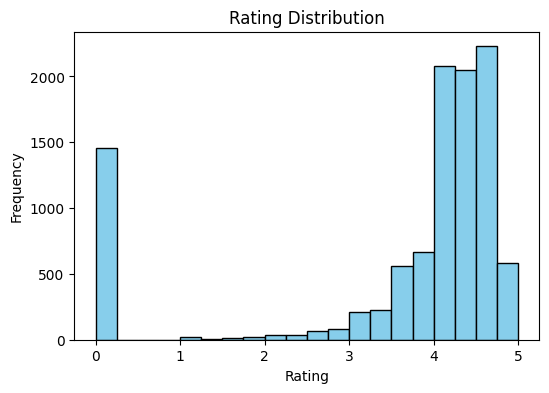

In [ ]:
col = 'Rating'   # yahan apna column name do

plt.figure(figsize=(6,4))
plt.hist(df[col], bins=20, color='skyblue', edgecolor='black')
plt.title(f"{col} Distribution")
plt.xlabel(col)
plt.ylabel("Frequency")
plt.show()


### Multiple Columns (Loop)

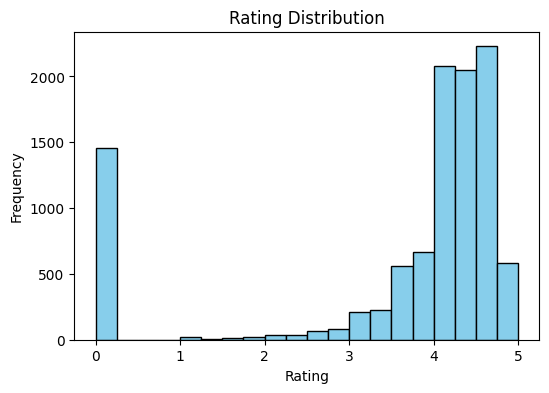

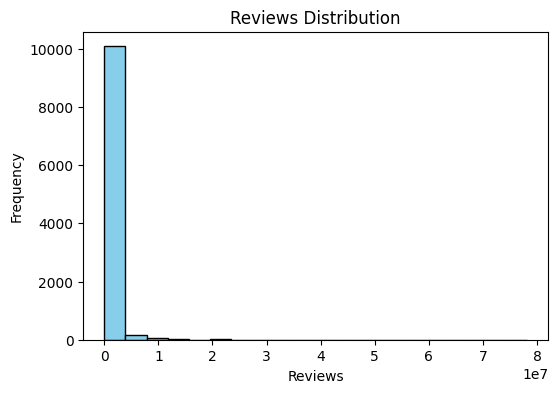

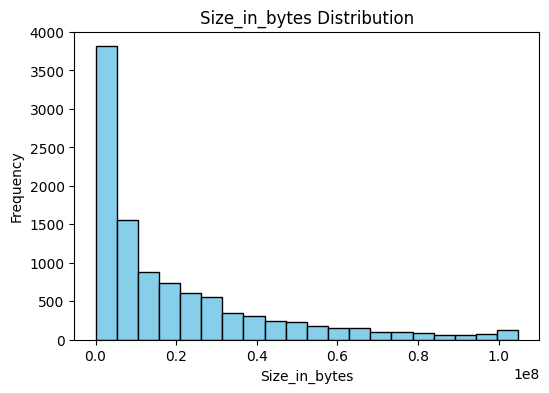

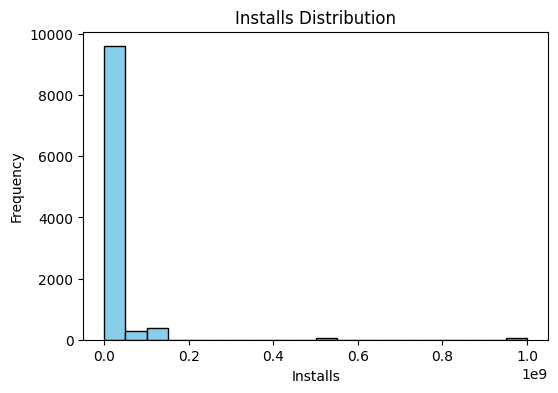

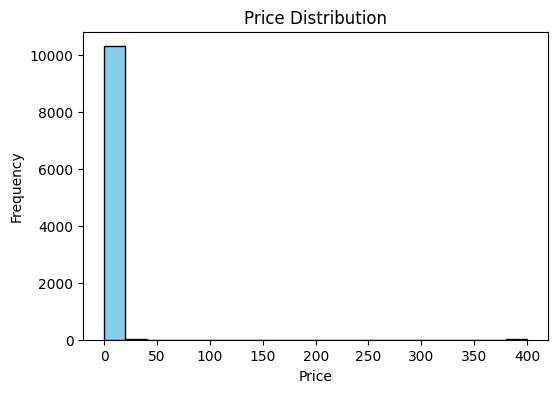

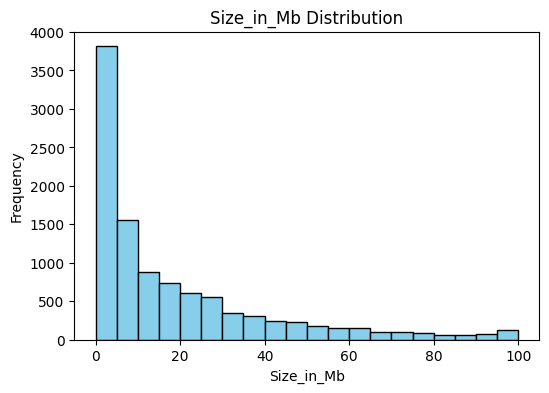

In [ ]:
numeric_cols = ['Rating', 'Reviews', 'Size_in_bytes', 'Installs', 'Price', 'Size_in_Mb']

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=20, color='skyblue', edgecolor='black')
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

### Histogram  (Presentation / Portfolio)

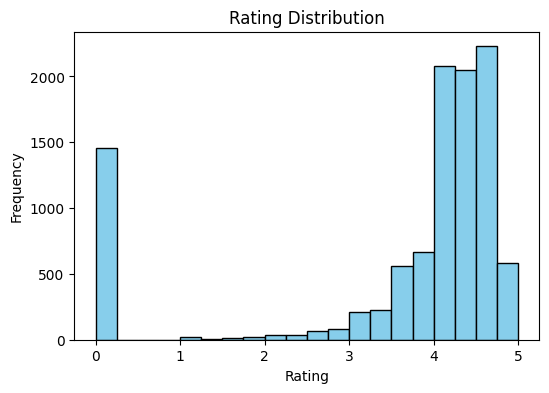

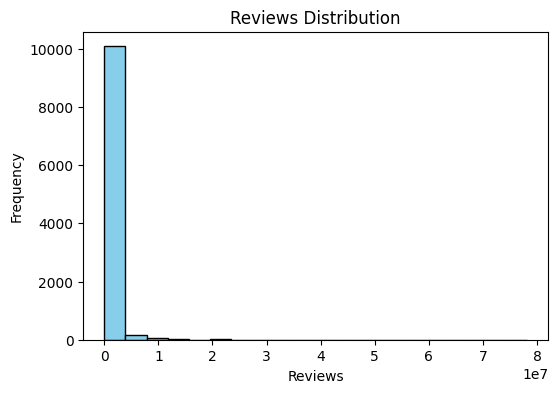

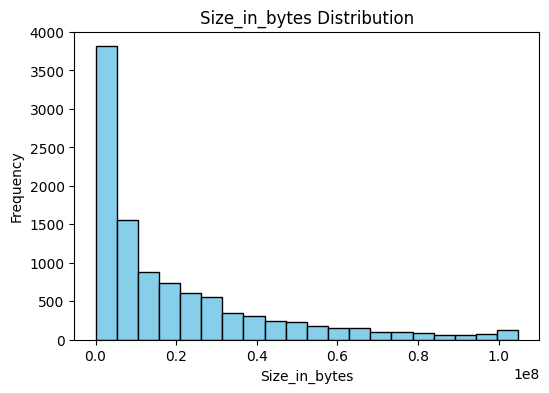

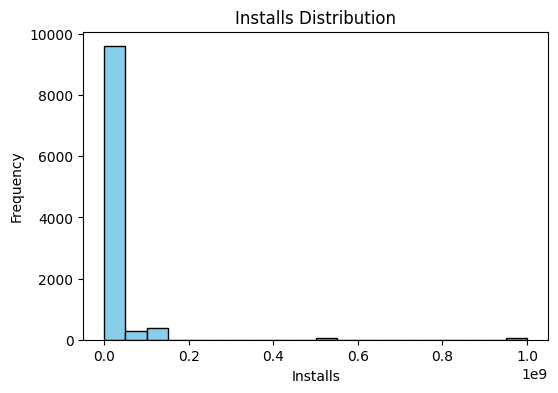

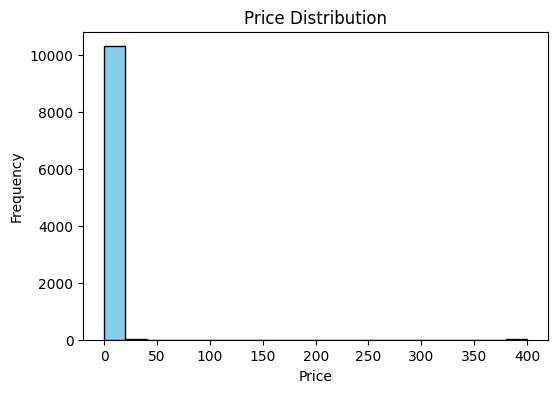

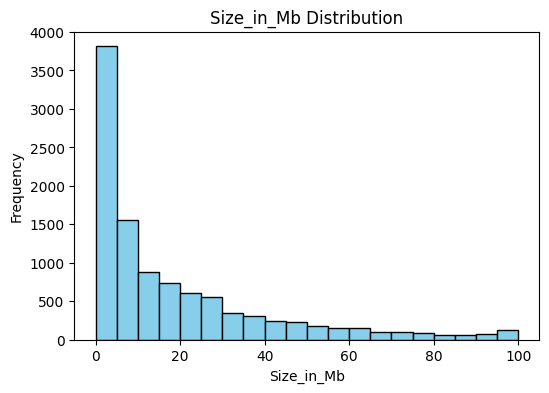

In [ ]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=20, color='skyblue', edgecolor='black')
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.savefig(f"{col}_histogram.png", dpi=300, bbox_inches='tight')
    plt.show()


# “I visualized the distribution of numeric features using histograms to understand the frequency and spread of values in the dataset.”

# Step 6: Outliers Detection (IQR Method)

In [ ]:
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]


### Outliers count:

In [ ]:
outliers.shape[0]


704

### Outliers visualization (Boxplot)

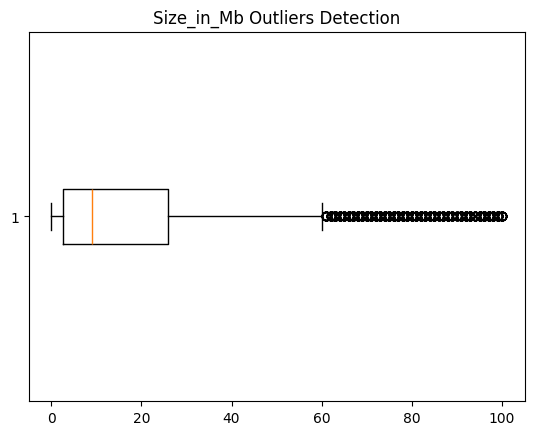

In [ ]:
plt.boxplot(df[col], vert=False)
plt.title(f"{col} Outliers Detection")
plt.show()

### Save:

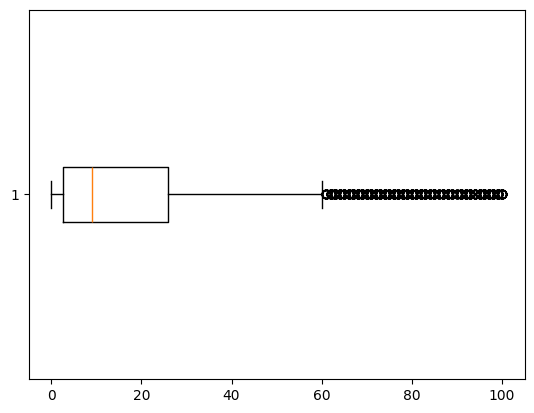

In [ ]:
plt.boxplot(df[col], vert=False)
plt.savefig(f"{col}_boxplot.png", dpi=300, bbox_inches='tight')
plt.show()

## All-in-One Summary

In [ ]:
summary = {
    "Mean": df[col].mean(),
    "Median": df[col].median(),
    "Min": df[col].min(),
    "Max": df[col].max(),
    "Std Dev": df[col].std(),
    "Outliers Count": outliers.shape[0]
}

pd.DataFrame(summary, index=[col])

,Mean,Median,Min,Max,Std Dev,Outliers Count
Size_in_Mb,18.165701,9.1,0.0,100.0,22.145816,704


## One-liner

“For numeric variables, I analyzed central tendency, spread, distribution, and detected outliers using the IQR method.”

# Step 7: Distribution Analysis

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

### Numeric Columns

In [ ]:
numeric_cols = ['Rating', 'Reviews', 'Size_in_bytes', 'Installs', 'Price', 'Size_in_Mb']


### Use Python built-in round() function

In [ ]:
skew_val = round(skew(df[col].dropna()), 2)   # ✅ sahi
kurt_val = round(kurtosis(df[col].dropna()), 2)  # ✅ sahi


## Full Corrected Distribution Analysis Code

=== Rating ===
Mean: 3.6, Median: 4.2, Min: 0.0, Max: 5.0, Std Dev: 1.54
Skewness: -1.71, Kurtosis: 1.35


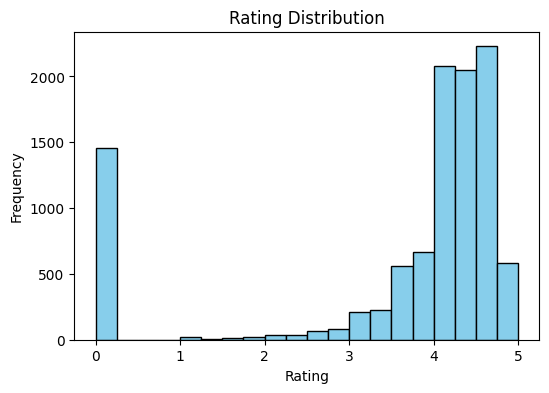



=== Reviews ===
Mean: 406333.77, Median: 1688.5, Min: 0.0, Max: 78158306.0, Std Dev: 2698179.07
Skewness: 17.46, Kurtosis: 394.53


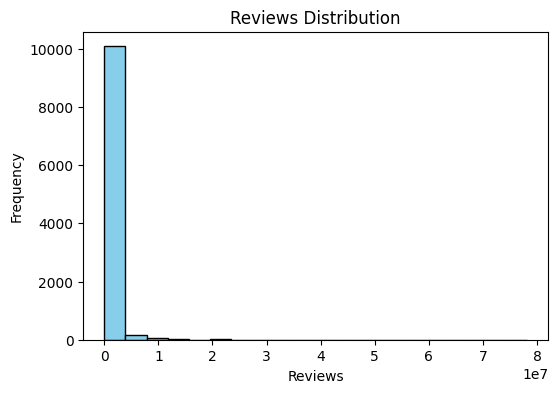



=== Size_in_bytes ===
Mean: 19048118.22, Median: 9542041.6, Min: 0.0, Max: 104857600.0, Std Dev: 23221570.76
Skewness: 1.71, Kurtosis: 2.52


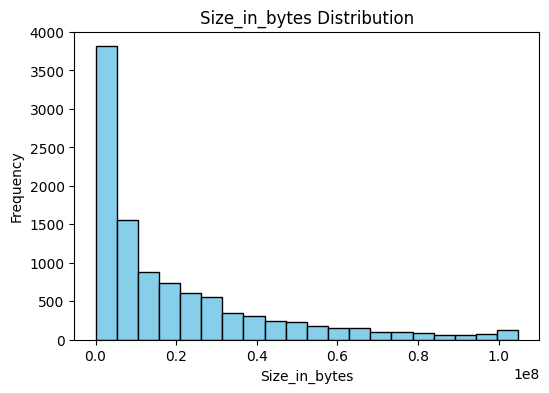



=== Installs ===
Mean: 14172659.72, Median: 100000.0, Min: 0.0, Max: 1000000000.0, Std Dev: 80280899.86
Skewness: 10.12, Kurtosis: 112.67


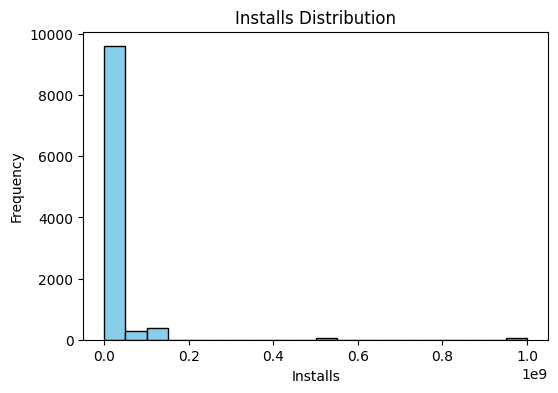



=== Price ===
Mean: 1.03, Median: 0.0, Min: 0.0, Max: 400.0, Std Dev: 16.29
Skewness: 23.31, Kurtosis: 556.63


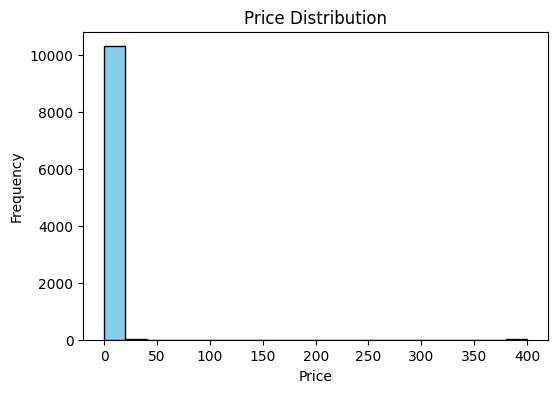



=== Size_in_Mb ===
Mean: 18.17, Median: 9.1, Min: 0.0, Max: 100.0, Std Dev: 22.15
Skewness: 1.71, Kurtosis: 2.52


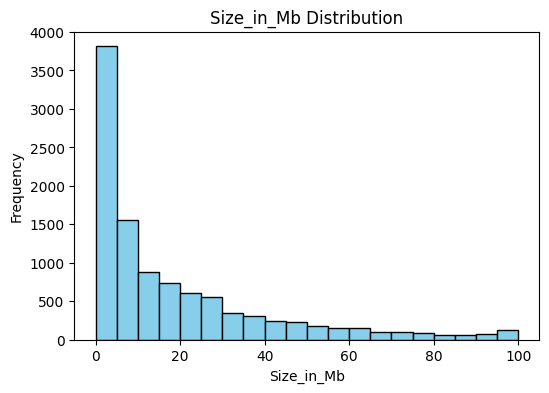

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

numeric_cols = ['Rating', 'Reviews', 'Size_in_bytes', 'Installs', 'Price', 'Size_in_Mb']

for col in numeric_cols:
    print(f"=== {col} ===")

    # Summary stats
    mean_val = round(df[col].mean(), 2)
    median_val = round(df[col].median(), 2)
    min_val = df[col].min()
    max_val = df[col].max()
    std_val = round(df[col].std(), 2)
    skew_val = round(skew(df[col].dropna()), 2)      # ✅ correct
    kurt_val = round(kurtosis(df[col].dropna()), 2)  # ✅ correct

    print(f"Mean: {mean_val}, Median: {median_val}, Min: {min_val}, Max: {max_val}, Std Dev: {std_val}")
    print(f"Skewness: {skew_val}, Kurtosis: {kurt_val}")

    # Histogram
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=20, color='skyblue', edgecolor='black')
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

    print("\n")


# Step 8: Correlation Analysis
Numeric columns  relationship
Pearson / Spearman correlation
Heatmap generate

### Numeric Columns

In [ ]:
numeric_cols = ['Rating', 'Reviews', 'Size_in_bytes', 'Installs', 'Price', 'Size_in_Mb']


### Pearson Correlation

In [ ]:
# Pearson Correlation (linear relationship)
pearson_corr = df[numeric_cols].corr(method='pearson')
print("=== Pearson Correlation ===")
print(pearson_corr)

=== Pearson Correlation ===
                 Rating   Reviews  Size_in_bytes  Installs     Price  \
Rating         1.000000  0.079550       0.102537  0.083886 -0.016277   
Reviews        0.079550  1.000000       0.070434  0.634987 -0.009424   
Size_in_bytes  0.102537  0.070434       1.000000  0.000170 -0.015086   
Installs       0.083886  0.634987       0.000170  1.000000 -0.011155   
Price         -0.016277 -0.009424      -0.015086 -0.011155  1.000000   
Size_in_Mb     0.102537  0.070434       1.000000  0.000170 -0.015086   

               Size_in_Mb  
Rating           0.102537  
Reviews          0.070434  
Size_in_bytes    1.000000  
Installs         0.000170  
Price           -0.015086  
Size_in_Mb       1.000000  


### Spearman Correlation

In [ ]:
# Spearman Correlation (monotonic relationship)
spearman_corr = df[numeric_cols].corr(method='spearman')
print("=== Spearman Correlation ===")
print(spearman_corr)

=== Spearman Correlation ===
                 Rating   Reviews  Size_in_bytes  Installs     Price  \
Rating         1.000000  0.434319       0.030945  0.360087  0.017634   
Reviews        0.434319  1.000000       0.038174  0.970695 -0.164073   
Size_in_bytes  0.030945  0.038174       1.000000  0.020737 -0.016533   
Installs       0.360087  0.970695       0.020737  1.000000 -0.238829   
Price          0.017634 -0.164073      -0.016533 -0.238829  1.000000   
Size_in_Mb     0.030945  0.038174       1.000000  0.020737 -0.016533   

               Size_in_Mb  
Rating           0.030945  
Reviews          0.038174  
Size_in_bytes    1.000000  
Installs         0.020737  
Price           -0.016533  
Size_in_Mb       1.000000  


### Heatmap Visualization (Pearson)

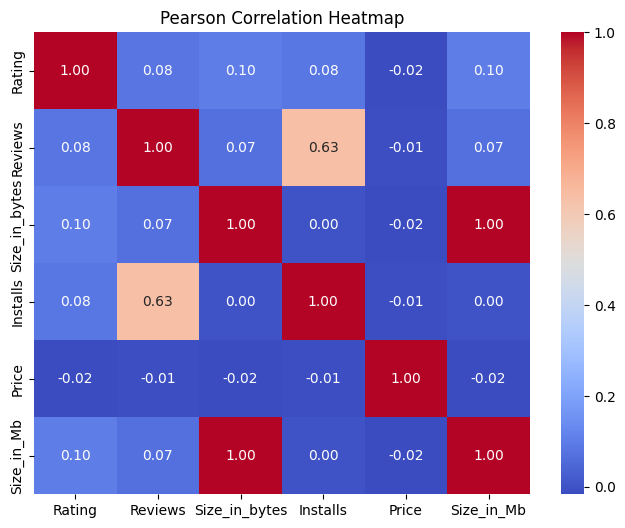

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Pearson Correlation Heatmap")
plt.show()

### Heatmap Visualization (Spearman)

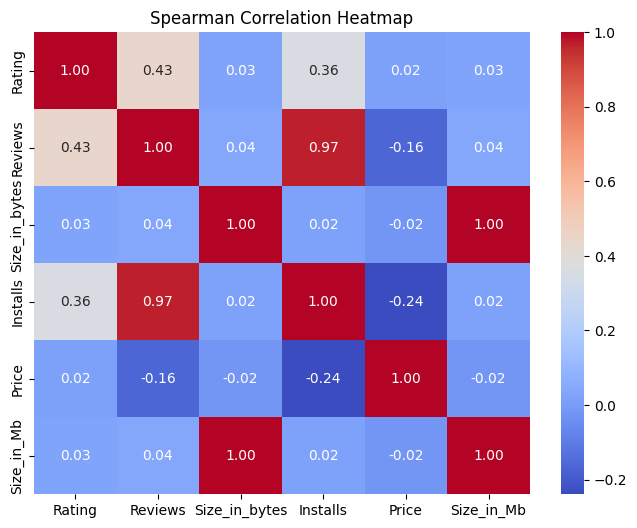

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Spearman Correlation Heatmap")
plt.show()

## “I performed correlation analysis for numeric features using both Pearson and Spearman methods, and visualized the relationships with heatmaps to identify linear and monotonic associations among variables.”

# Step 9: Interaction & Alerts Generate hotay hain
ydata-profiling automatic warnings deta hai:
High correlation detected
High missing values
Zero variance columns
Constant columns

### High Missing Values Check

In [ ]:
# Missing values percentage per column
missing_percent = df.isnull().mean() * 100

# High missing threshold = 30% (adjustable)
high_missing = missing_percent[missing_percent > 30]

print("=== Columns with High Missing Values (>30%) ===")
print(high_missing)

=== Columns with High Missing Values (>30%) ===
Series([], dtype: float64)


### Zero Variance / Constant Columns

In [ ]:
# Variance per column
variance = df.var(numeric_only=True)

# Zero variance columns
zero_variance_cols = variance[variance == 0].index.tolist()
print("=== Numeric Columns with Zero Variance ===")
print(zero_variance_cols)

# Constant categorical columns
constant_categorical = [col for col in df.select_dtypes(include='object').columns if df[col].nunique() == 1]
print("=== Constant Categorical Columns ===")
print(constant_categorical)


=== Numeric Columns with Zero Variance ===
[]
=== Constant Categorical Columns ===
[]


### High Correlation Detection

In [ ]:
import pandas as pd
import numpy as np

numeric_cols = df.select_dtypes(include='number').columns
corr_matrix = df[numeric_cols].corr().abs()  # absolute value

# Upper triangle of correlation matrix
upper_tri = corr_matrix.where(~np.tril(np.ones(corr_matrix.shape)).astype(bool))

# High correlation threshold = 0.8
high_corr_pairs = [(col1, col2, upper_tri.loc[col1, col2])
                   for col1 in upper_tri.columns
                   for col2 in upper_tri.columns
                   if pd.notnull(upper_tri.loc[col1, col2]) and upper_tri.loc[col1, col2] > 0.8]

print("=== Highly Correlated Numeric Column Pairs (>|0.8|) ===")
print(high_corr_pairs)


=== Highly Correlated Numeric Column Pairs (>|0.8|) ===
[('Size_in_bytes', 'Size_in_Mb', np.float64(1.0))]


## “I generated automatic data quality alerts manually by checking for high missing values, constant columns, zero variance features, and highly correlated numeric features to identify potential issues before modeling.”

# Step 10: Data Type Validation

Incorrect data types detect
Example:
Numbers stored as strings
Dates in wrong format

### Check Numeric Columns Stored as Strings

In [ ]:
# Select object type columns
object_cols = df.select_dtypes(include='object').columns

numeric_as_str = []

for col in object_cols:
    # Try converting to numeric
    try:
        pd.to_numeric(df[col].dropna())
        numeric_as_str.append(col)
    except:
        pass

print("=== Object Columns that can be converted to Numeric ===")
print(numeric_as_str)

=== Object Columns that can be converted to Numeric ===
[]


### Check Date Columns (Incorrect Format)

In [ ]:
# Example: columns that are supposed to be dates
date_cols = ['Last_Updated', 'Release_Date']  # replace with tumhare dataset ke date columns

invalid_dates = []

for col in date_cols:
    try:
        pd.to_datetime(df[col])
    except:
        invalid_dates.append(col)

print("=== Date Columns with Invalid Format ===")
print(invalid_dates)


=== Date Columns with Invalid Format ===
['Last_Updated', 'Release_Date']


## Optional  Convert Automatically
### Numeric conversion

In [ ]:
for col in numeric_as_str:
    df[col] = pd.to_numeric(df[col], errors='coerce')

### Date conversion

In [ ]:
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size_in_bytes', 'Installs',
       'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated',
       'Current Ver', 'Android Ver', 'Installs_category', 'Size_in_Mb'],
      dtype='object')

In [ ]:
# Suppose your dataset has a column named 'Updated'
date_cols = ['Updated']  # replace with actual column name

In [ ]:
invalid_dates = []

for col in date_cols:
    try:
        pd.to_datetime(df[col])
    except:
        invalid_dates.append(col)

print("=== Date Columns with Invalid Format ===")
print(invalid_dates)

=== Date Columns with Invalid Format ===
['Updated']


In [ ]:
for col in df.columns:
    print(col, df[col].dtype)

App object
Category object
Rating float64
Reviews float64
Size_in_bytes float64
Installs float64
Type object
Price float64
Content Rating object
Genres object
Last Updated object
Current Ver object
Android Ver object
Installs_category object
Size_in_Mb float64


## “After validating data types, I ensured that all numeric columns were correctly stored as numbers, all date columns had the proper datetime format, and no inconsistencies remained in the dataset, making it ready for accurate analysis and modeling.”

🔹 Short Version (Slide / Bullet ):

### Ensured numeric columns are stored correctly

### Checked and fixed date columns format

### Removed inconsistencies to prepare clean dataset for analysis

# Step 11: Summary & Report Generation

### Analysis combine hota hai

### Interactive HTML report generate

## Sections:

### Overview

### Variables

### Interactions

### Correlations

### Missing values

# Libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

###  Numeric Columns

In [ ]:
numeric_cols = ['Rating', 'Reviews', 'Size_in_bytes', 'Installs', 'Price', 'Size_in_Mb']

### Overview

In [ ]:
overview = {
    "Total Rows": df.shape[0],
    "Total Columns": df.shape[1],
    "Missing Values": df.isnull().sum().sum(),
    "Duplicate Rows": df.duplicated().sum(),
    "Memory Usage (MB)": round(df.memory_usage(deep=True).sum() / (1024**2), 2)
}

overview_df = pd.DataFrame(overview, index=[0])

### Variables Summary (Numeric Columns)

In [ ]:
variables_summary = pd.DataFrame({
    "Column": numeric_cols,
    "Mean": df[numeric_cols].mean().round(2).values,
    "Median": df[numeric_cols].median().round(2).values,
    "Min": df[numeric_cols].min().values,
    "Max": df[numeric_cols].max().values,
    "Std Dev": df[numeric_cols].std().round(2).values
})

### Correlation

In [ ]:
pearson_corr = df[numeric_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.close()

### Missing Values per Column

In [ ]:
missing_values = pd.DataFrame({
    "Column": df.columns,
    "Missing Count": df.isnull().sum(),
    "Missing (%)": (df.isnull().mean()*100).round(2)
})

### Alerts (Optional)

In [ ]:
# High missing values (>30%)
high_missing = missing_values[missing_values['Missing (%)'] > 30]

# Zero variance numeric columns
zero_variance_cols = [col for col in numeric_cols if df[col].var() == 0]

# Constant categorical columns
constant_categorical = [col for col in df.select_dtypes(include='object').columns if df[col].nunique() == 1]

# High correlation pairs (>0.8)
upper_tri = pearson_corr.where(np.triu(np.ones(pearson_corr.shape), k=1).astype(bool))
high_corr_pairs = [(col1, col2, upper_tri.loc[col1, col2])
                   for col1 in upper_tri.columns
                   for col2 in upper_tri.columns
                   if pd.notnull(upper_tri.loc[col1, col2]) and upper_tri.loc[col1, col2] > 0.8]

### Generate HTML Report

In [ ]:
with open("EDA_Report.html", "w") as f:
    f.write("<h1>Dataset EDA Report</h1>")
    f.write("<h2>1. Overview</h2>")
    f.write(overview_df.to_html(index=False))

    f.write("<h2>2. Variables Summary (Numeric)</h2>")
    f.write(variables_summary.to_html(index=False))

    f.write("<h2>3. Correlations</h2>")
    f.write('<img src="correlation_heatmap.png" width="600">')

    f.write("<h2>4. Missing Values</h2>")
    f.write(missing_values.to_html(index=False))

    f.write("<h2>5. Alerts</h2>")
    f.write(f"<p>High Missing Columns (>30%): {high_missing['Column'].tolist()}</p>")
    f.write(f"<p>Zero Variance Numeric Columns: {zero_variance_cols}</p>")
    f.write(f"<p>Constant Categorical Columns: {constant_categorical}</p>")
    f.write(f"<p>Highly Correlated Pairs (>0.8): {high_corr_pairs}</p>")

In [ ]:
print(overview_df.head())
print(variables_summary.head())
print(missing_values.head())
print(high_missing)
print(zero_variance_cols)
print(constant_categorical)
print(high_corr_pairs)


   Total Rows  Total Columns  Missing Values  Duplicate Rows  \
0       10346             15               0               0   

   Memory Usage (MB)  
0               5.79  
          Column         Mean     Median  Min           Max      Std Dev
0         Rating         3.60        4.2  0.0  5.000000e+00         1.54
1        Reviews    406333.77     1688.5  0.0  7.815831e+07   2698179.07
2  Size_in_bytes  19048118.22  9542041.6  0.0  1.048576e+08  23221570.76
3       Installs  14172659.72   100000.0  0.0  1.000000e+09  80280899.86
4          Price         1.03        0.0  0.0  4.000000e+02        16.29
                      Column  Missing Count  Missing (%)
App                      App              0          0.0
Category            Category              0          0.0
Rating                Rating              0          0.0
Reviews              Reviews              0          0.0
Size_in_bytes  Size_in_bytes              0          0.0
Empty DataFrame
Columns: [Column, Missing Cou

In [ ]:
# sirf numeric columns select karo
numeric_cols = df.select_dtypes(include='number').columns
corr = df[numeric_cols].corr()

# Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.savefig("/content/correlation_heatmap.png")
plt.close()

## “I generated a complete EDA report combining overview, numeric variable summaries, correlations, missing values, and data quality alerts in an interactive HTML format for easy visualization and presentation.”

In [ ]:
from google.colab import files

files.download("/content/EDA_Report.html")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
pip install ydata-profiling


In [ ]:
from ydata_profiling import ProfileReport
import pandas as pd
from IPython.display import IFrame

# CSV load karo
df = pd.read_csv("/content/google_play_store_updated.csv")

# Profile report
profile = ProfileReport(df, title="EDA Report", explorative=True)

# HTML file save karo
profile.to_file("/content/EDA_Profile_Report.html")

# Notebook me iframe me display
IFrame("/content/EDA_Profile_Report.html", width=1000, height=600)


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 15/15 [00:01<00:00,  9.81it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# from google.colab import files
files.download("/content/EDA_Profile_Report.html")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Only if not installed
!pip install ydata-profiling pandas matplotlib seaborn


In [ ]:
# from google.colab import files
# import pandas as pd

# # Upload CSV
# uploaded = files.upload()  # Dialog open hoga, CSV select karo

# # Get the filename
# filename = list(uploaded.keys())[0]

# # Read CSV
# df = pd.read_csv('google_play_store_updated.csv')

# # Check first 5 rows
# df.head()


In [ ]:
# Total rows, columns, missing values, duplicates, memory usage
overview = pd.DataFrame({
    "Total Rows": [df.shape[0]],
    "Total Columns": [df.shape[1]],
    "Missing Values": [df.isnull().sum().sum()],
    "Duplicate Rows": [df.duplicated().sum()],
    "Memory Usage (MB)": [df.memory_usage(deep=True).sum() / (1024*1024)]
})
overview


,Total Rows,Total Columns,Missing Values,Duplicate Rows,Memory Usage (MB)
0,10346,15,0,0,5.787431


In [ ]:
numeric_cols = df.select_dtypes(include='number').columns
variables_summary = df[numeric_cols].describe().T
variables_summary['median'] = df[numeric_cols].median()
variables_summary = variables_summary[['mean','median','min','max','std']]
variables_summary


,mean,median,min,max,std
Rating,3.596965e+00,4.2,0.0,5.000000e+00,1.536360e+00
Reviews,4.063338e+05,1688.5,0.0,7.815831e+07,2.698179e+06
Size_in_bytes,1.904812e+07,9542041.6,0.0,1.048576e+08,2.322157e+07
Installs,1.417266e+07,100000.0,0.0,1.000000e+09,8.028090e+07
Price,1.031561e+00,0.0,0.0,4.000000e+02,1.628725e+01
Size_in_Mb,1.816570e+01,9.1,0.0,1.000000e+02,2.214582e+01


In [ ]:
numeric_cols = df.select_dtypes(include='number').columns
variables_summary = df[numeric_cols].describe().T
variables_summary['median'] = df[numeric_cols].median()
variables_summary = variables_summary[['mean','median','min','max','std']]
variables_summary

,mean,median,min,max,std
Rating,3.596965e+00,4.2,0.0,5.000000e+00,1.536360e+00
Reviews,4.063338e+05,1688.5,0.0,7.815831e+07,2.698179e+06
Size_in_bytes,1.904812e+07,9542041.6,0.0,1.048576e+08,2.322157e+07
Installs,1.417266e+07,100000.0,0.0,1.000000e+09,8.028090e+07
Price,1.031561e+00,0.0,0.0,4.000000e+02,1.628725e+01
Size_in_Mb,1.816570e+01,9.1,0.0,1.000000e+02,2.214582e+01


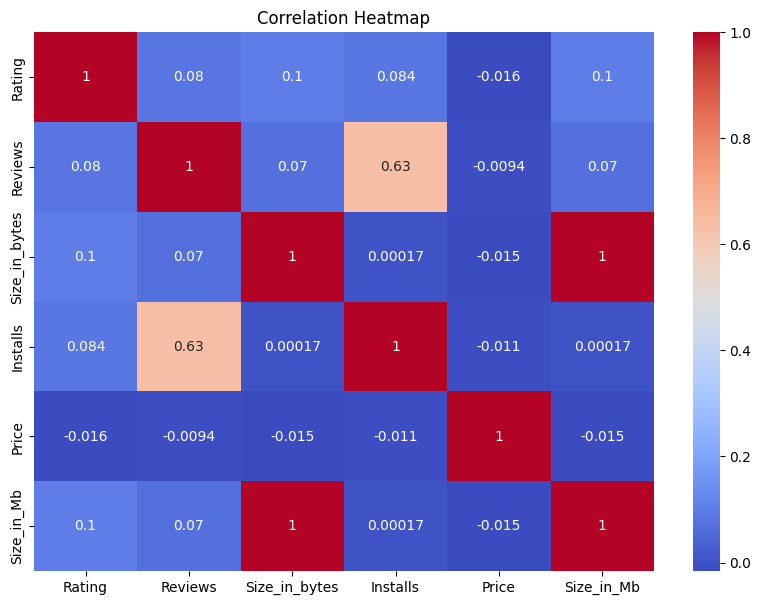

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,7))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.savefig("/content/correlation_heatmap.png")
plt.show()

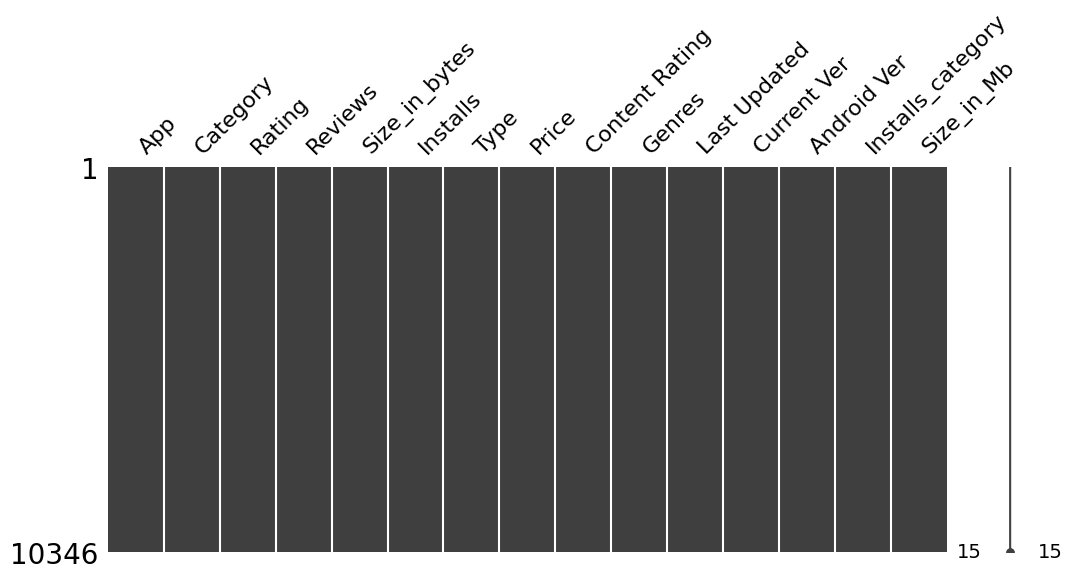

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))


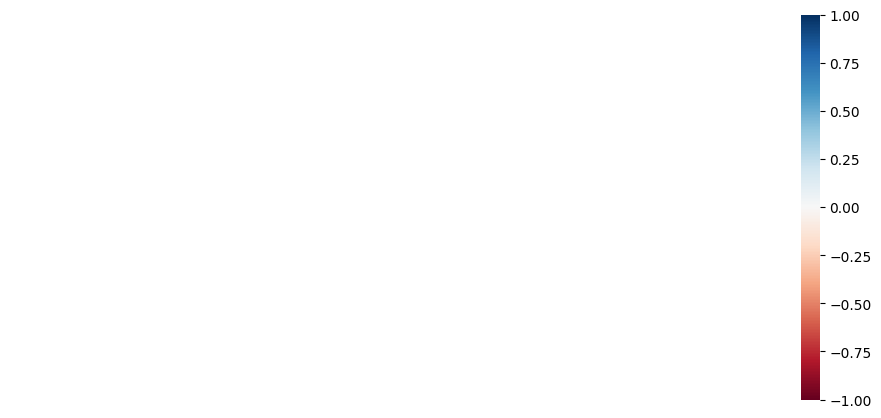

In [ ]:
import missingno as msno

# Install missingno if not installed
# !pip install missingno

# Matrix of missing values
msno.matrix(df, figsize=(12,5))
plt.show()

# Heatmap of missing correlations
msno.heatmap(df, figsize=(12,5))
plt.show()

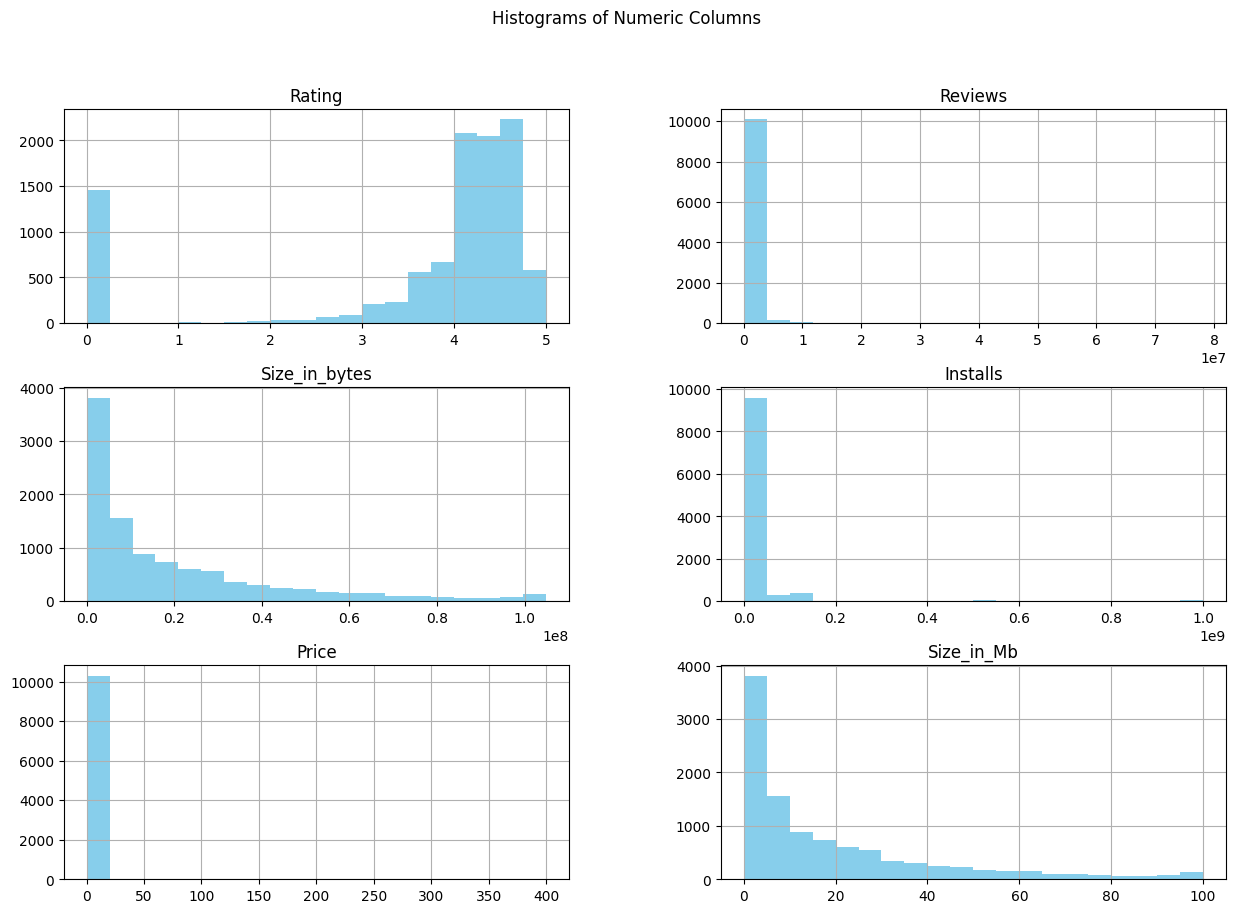

In [ ]:
df[numeric_cols].hist(figsize=(15,10), bins=20, color='skyblue')
plt.suptitle("Histograms of Numeric Columns")
plt.show()

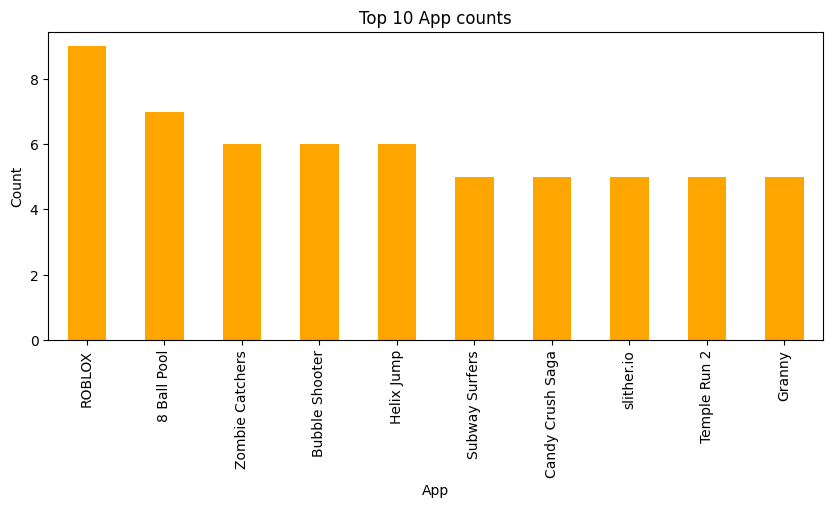

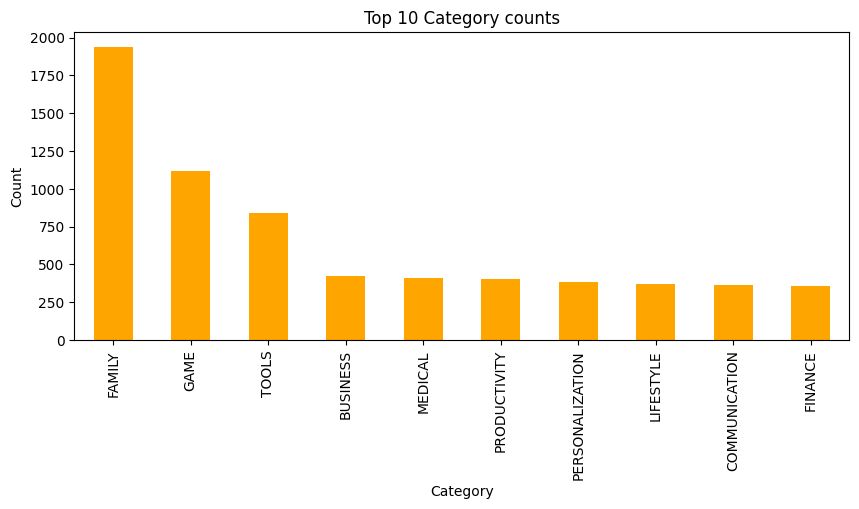

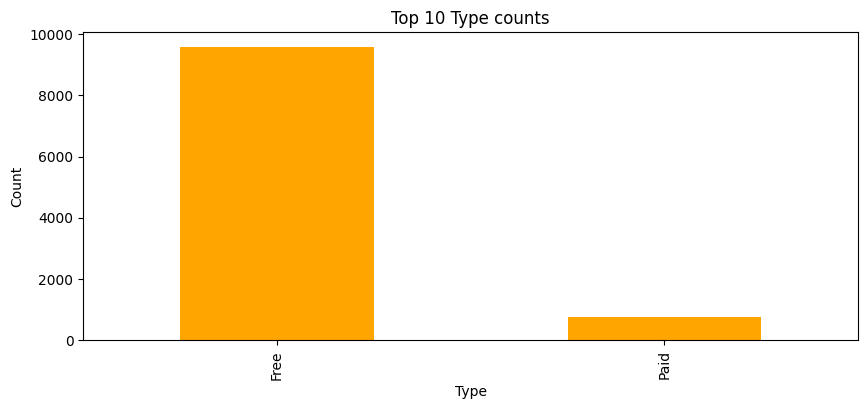

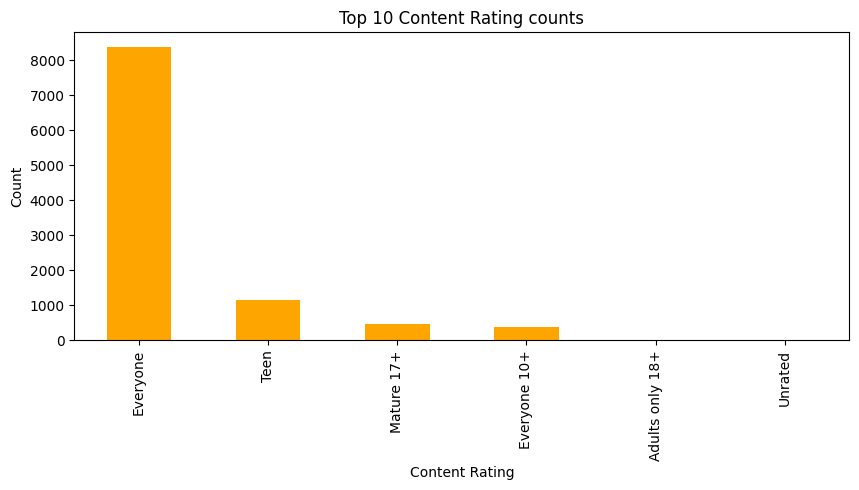

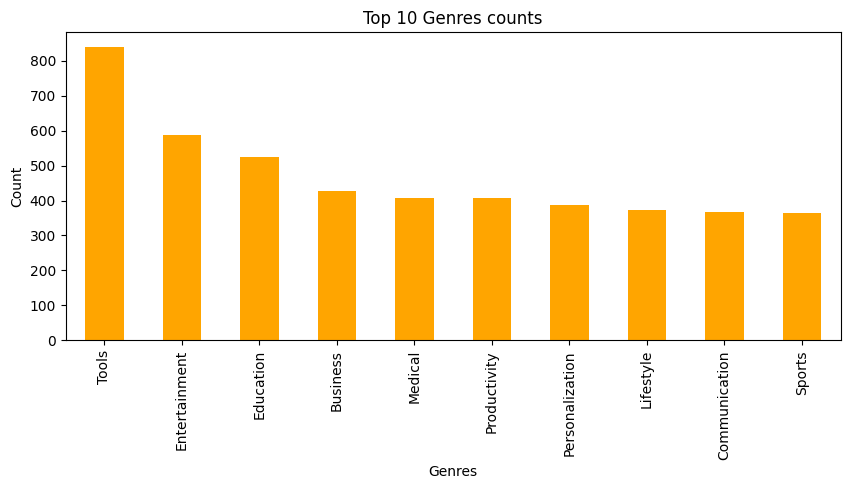

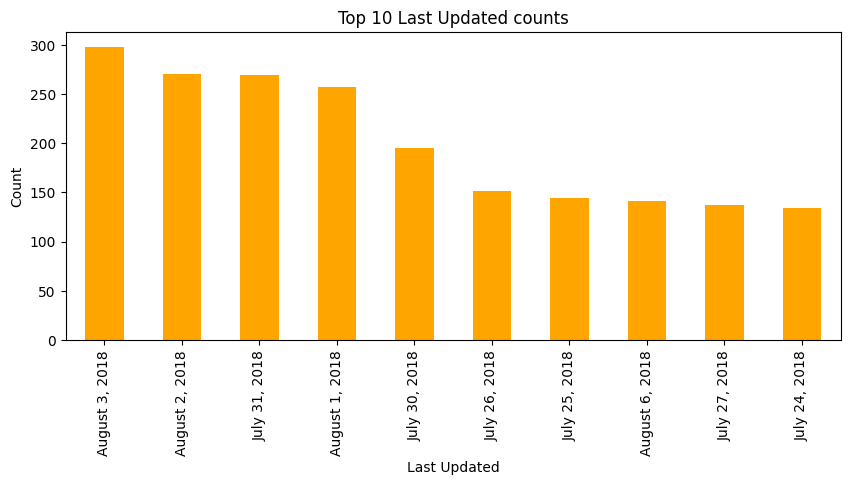

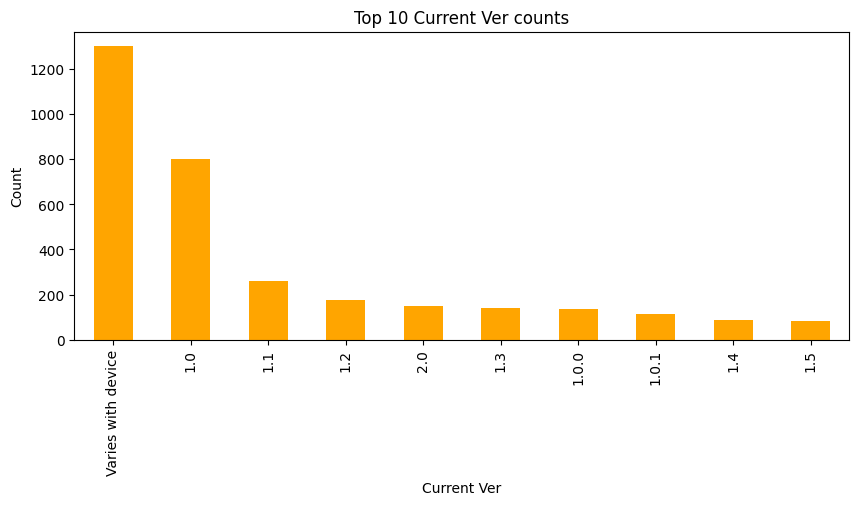

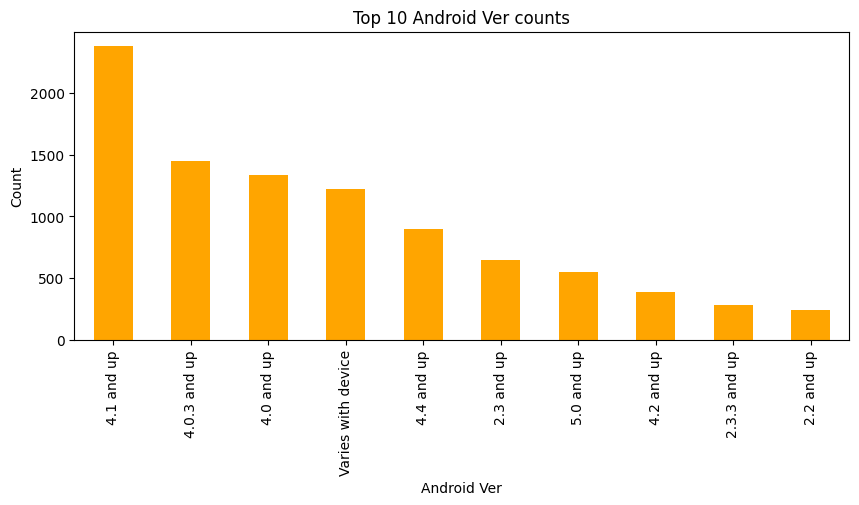

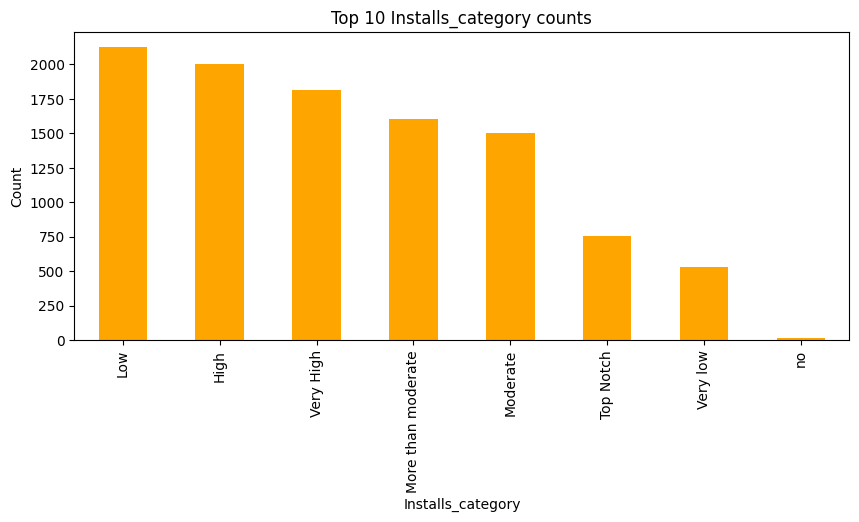

In [ ]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    plt.figure(figsize=(10,4))
    df[col].value_counts().head(10).plot(kind='bar', color='orange')
    plt.title(f"Top 10 {col} counts")
    plt.ylabel("Count")
    plt.show()

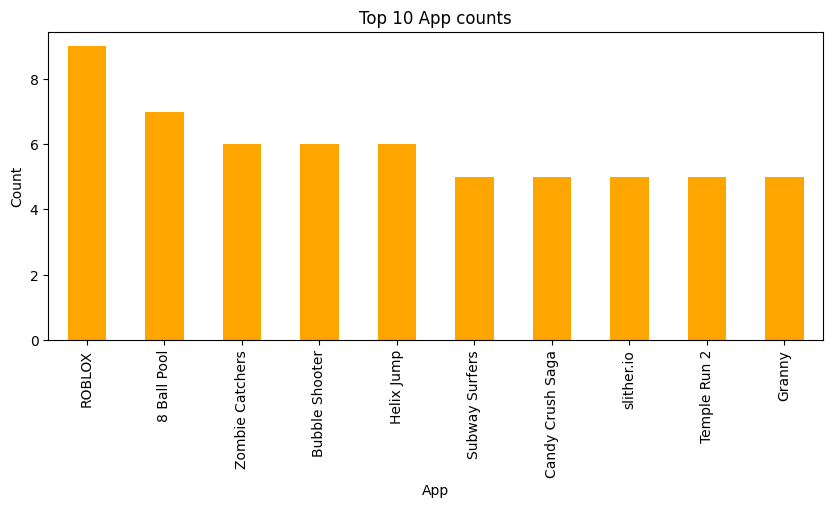

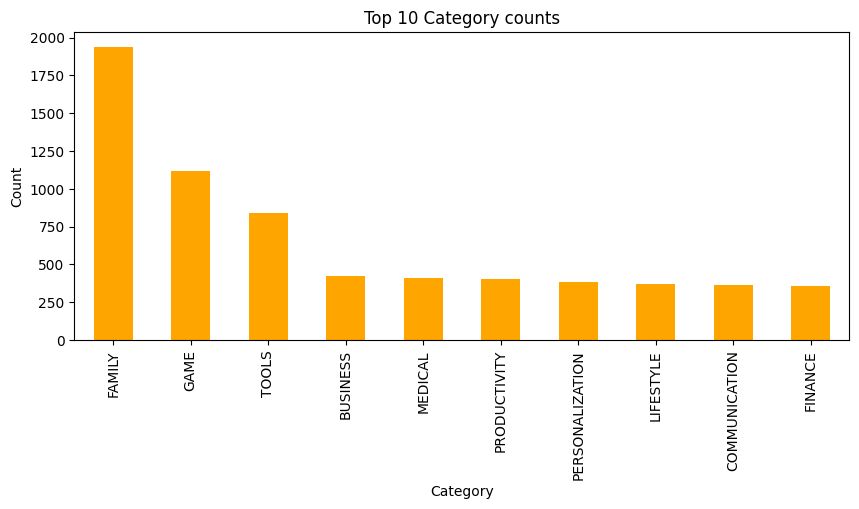

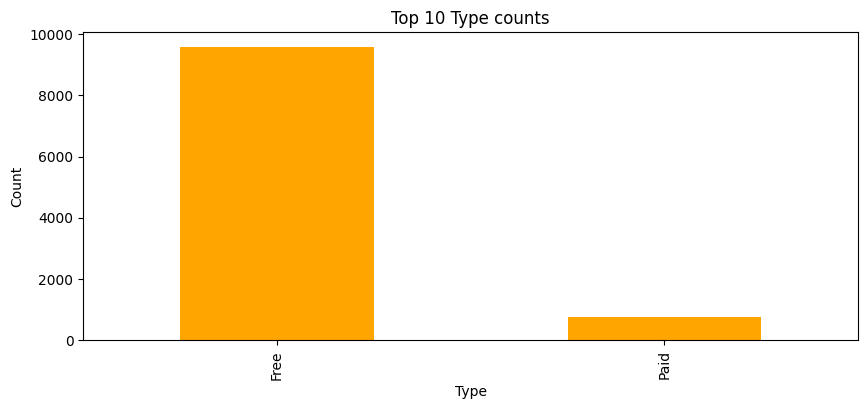

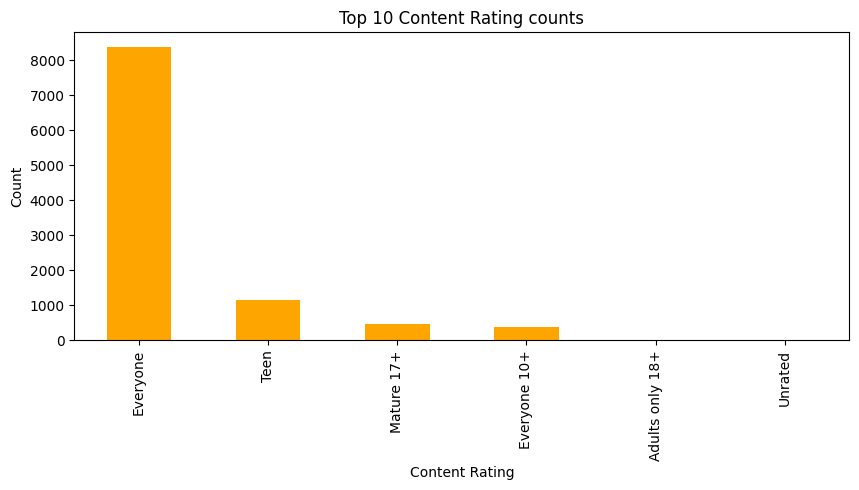

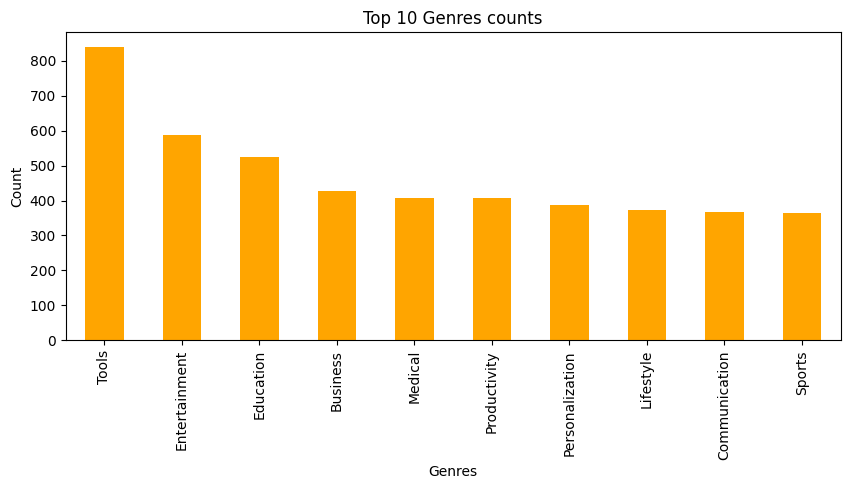

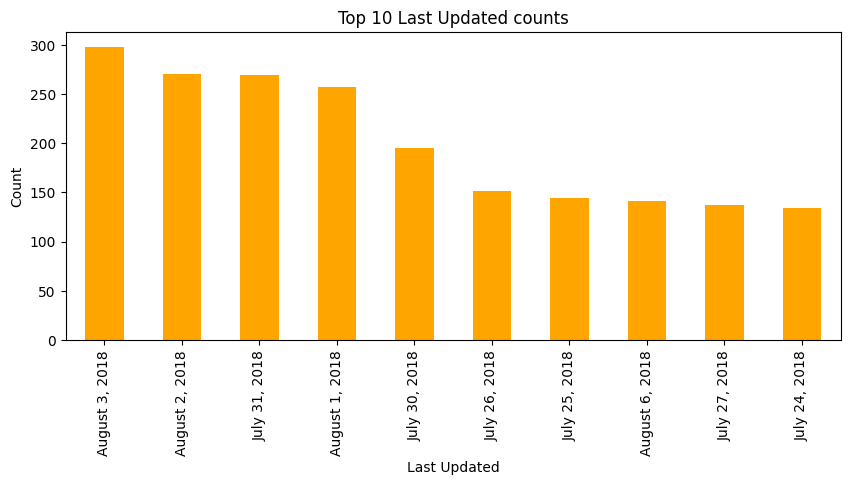

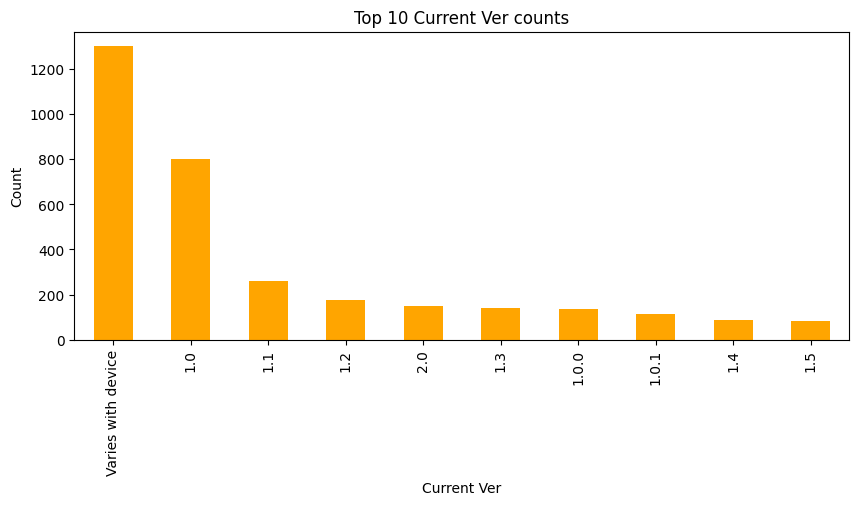

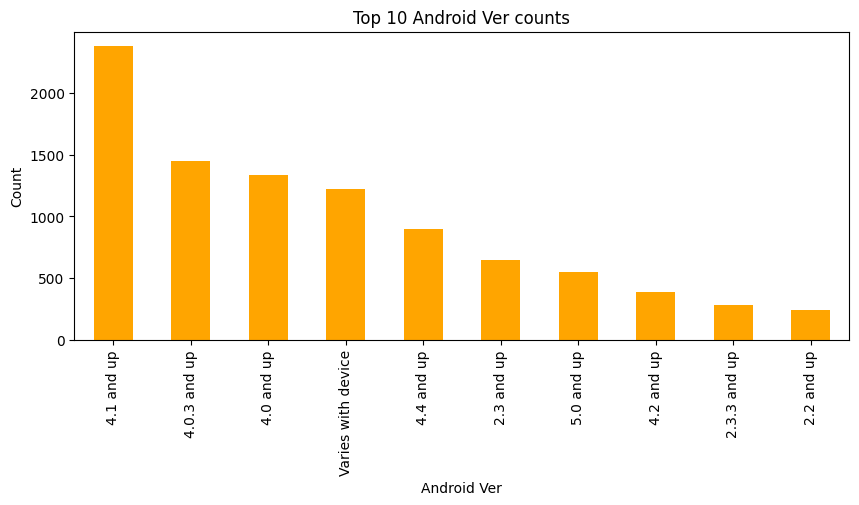

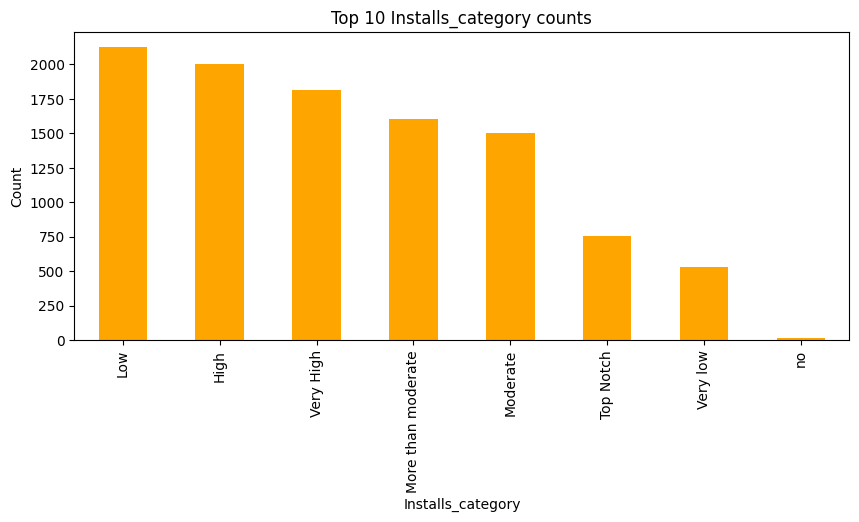

In [ ]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    plt.figure(figsize=(10,4))
    df[col].value_counts().head(10).plot(kind='bar', color='orange')
    plt.title(f"Top 10 {col} counts")
    plt.ylabel("Count")
    plt.show()

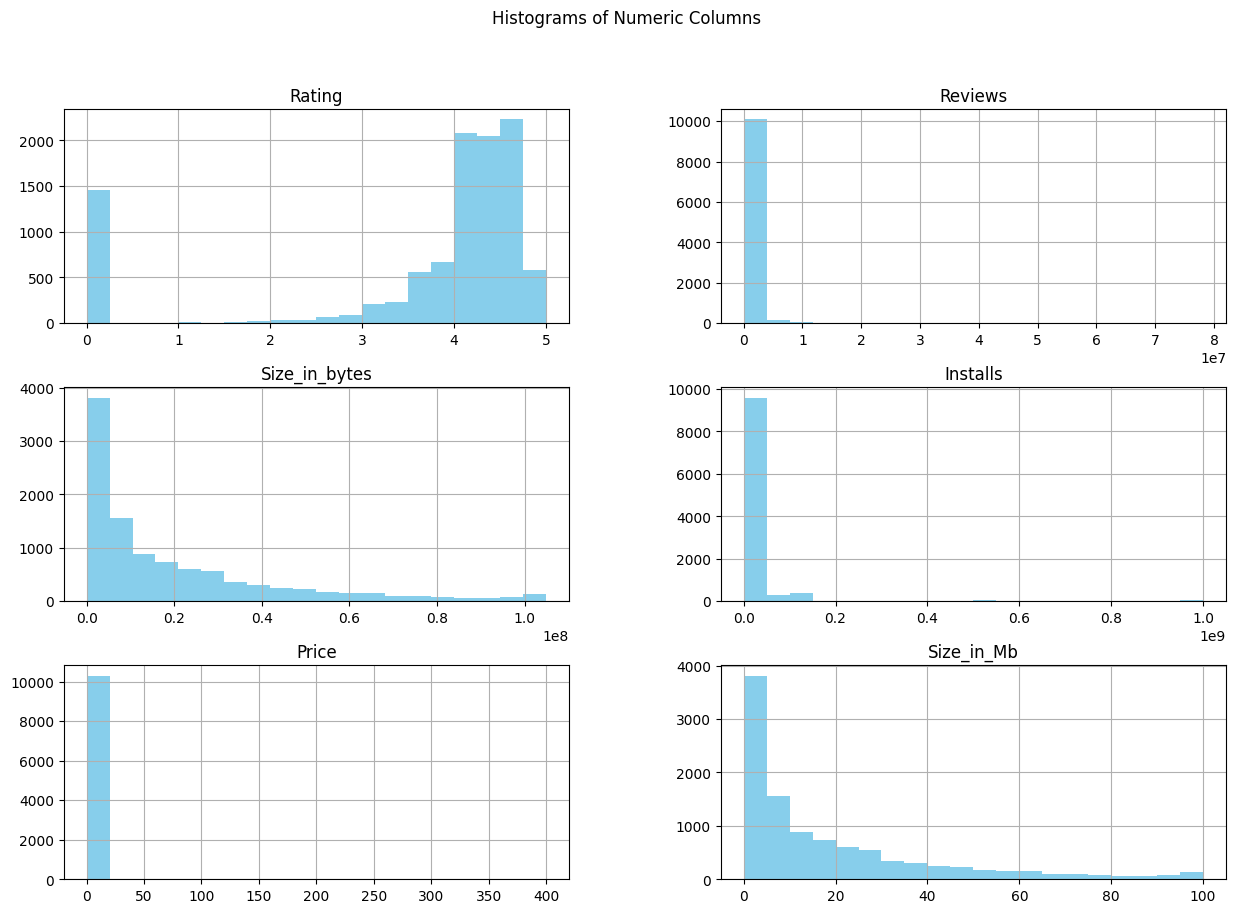

In [ ]:
df[numeric_cols].hist(figsize=(15,10), bins=20, color='skyblue')
plt.suptitle("Histograms of Numeric Columns")
plt.show()

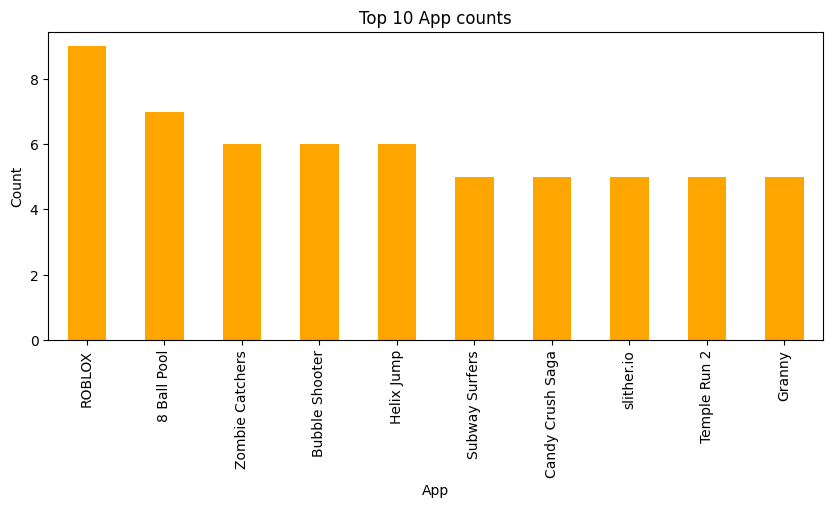

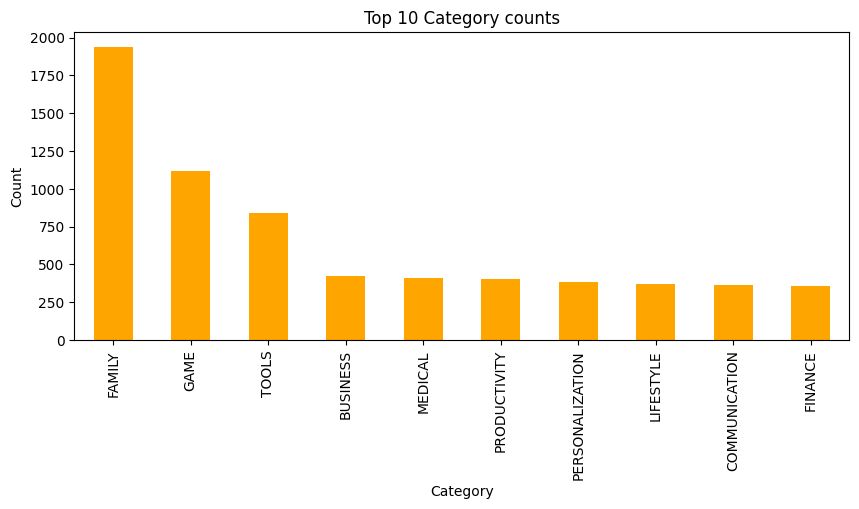

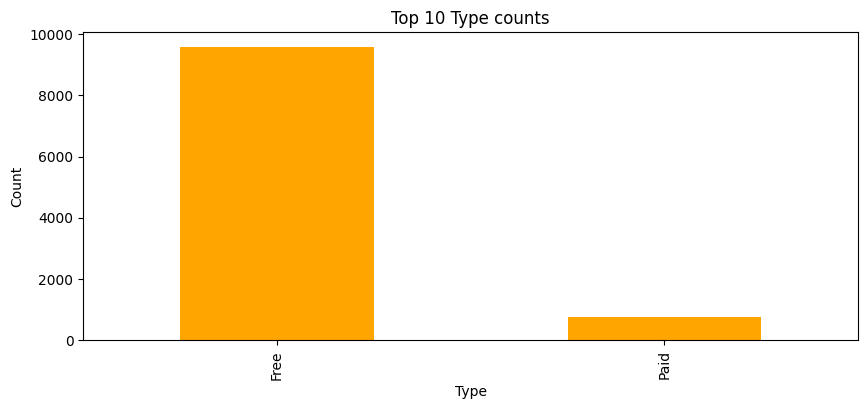

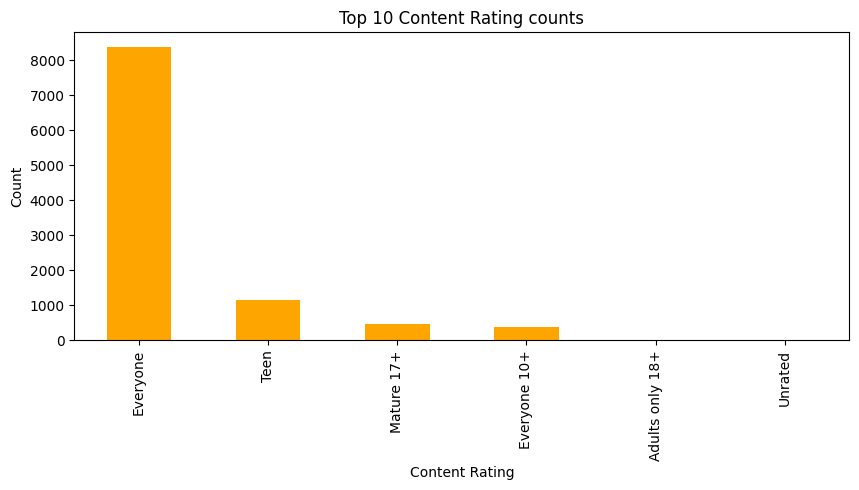

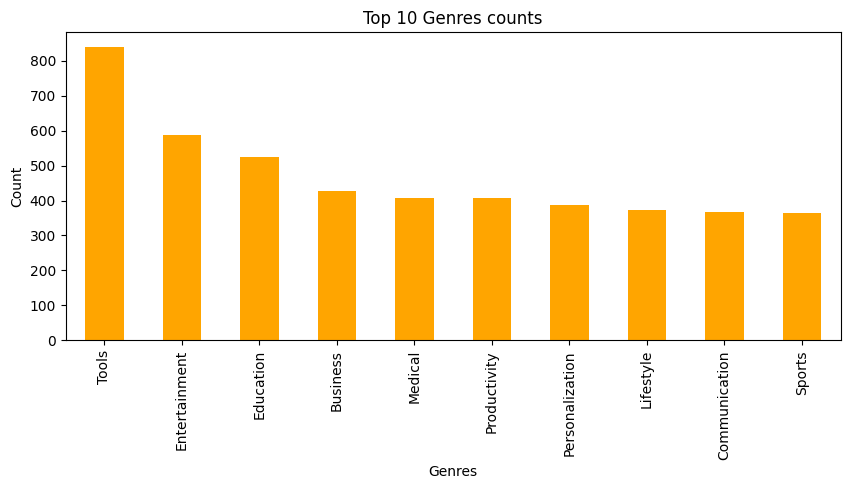

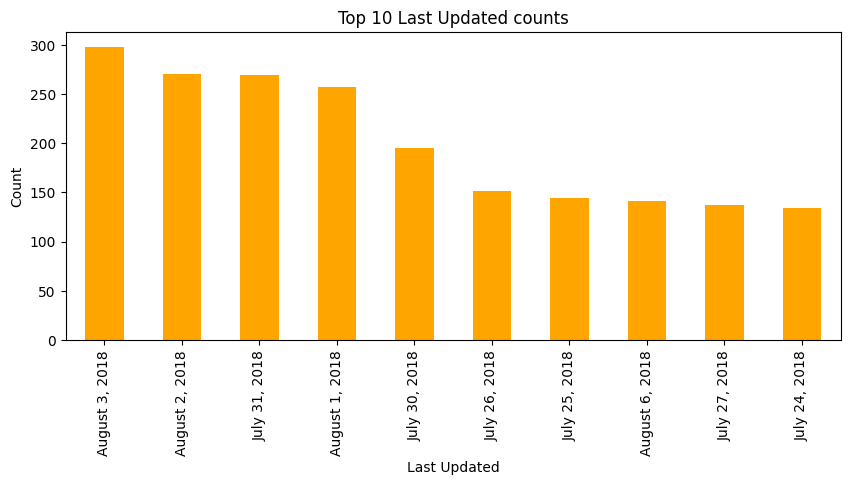

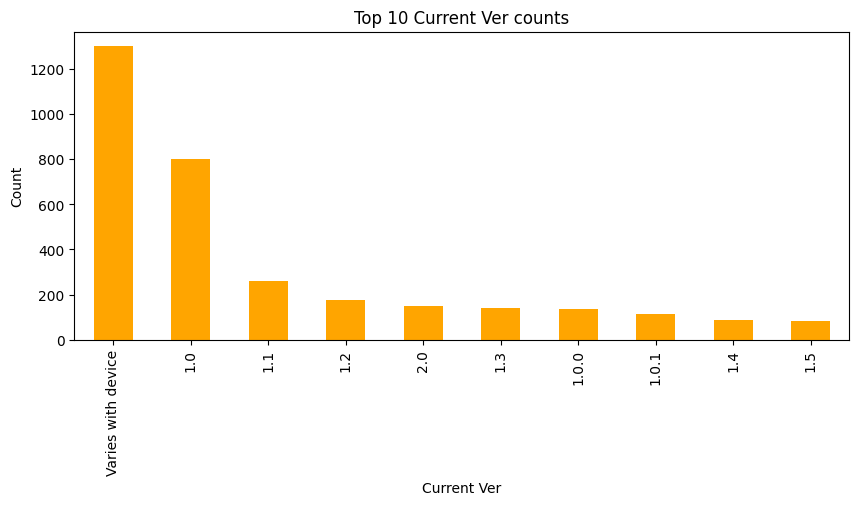

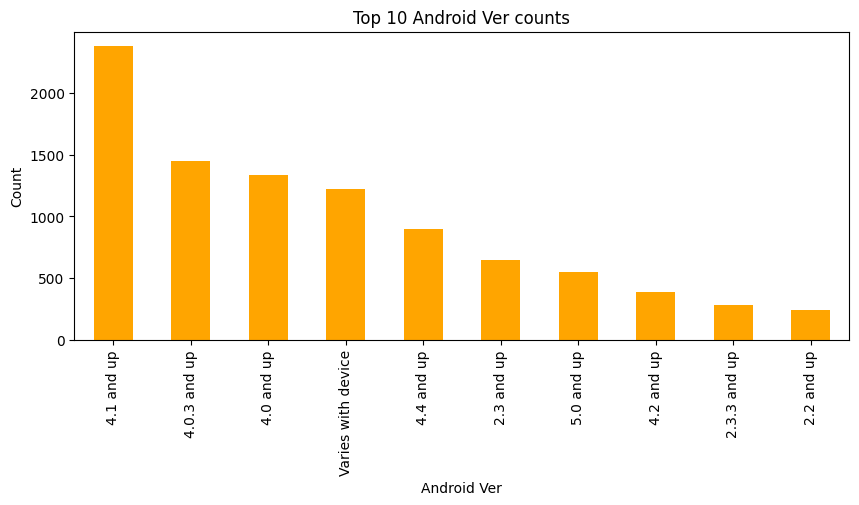

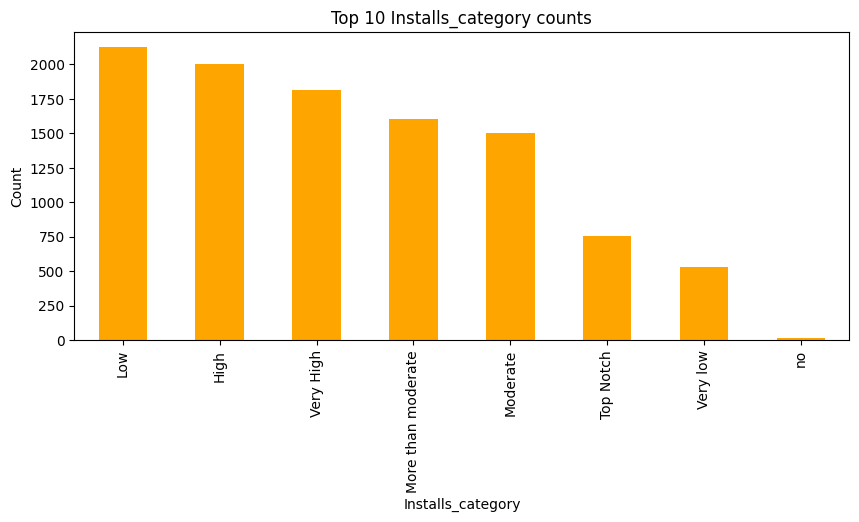

In [ ]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    plt.figure(figsize=(10,4))
    df[col].value_counts().head(10).plot(kind='bar', color='orange')
    plt.title(f"Top 10 {col} counts")
    plt.ylabel("Count")
    plt.show()

In [ ]:
# Zero variance numeric
zero_var_cols = [col for col in numeric_cols if df[col].nunique() <= 1]

# Constant categorical
constant_cat_cols = [col for col in categorical_cols if df[col].nunique() <= 1]

# Highly correlated pairs (>0.8)
corr_matrix = df[numeric_cols].corr()
high_corr_pairs = [(i,j,corr_matrix.loc[i,j]) for i in numeric_cols for j in numeric_cols if i!=j and abs(corr_matrix.loc[i,j])>0.8]

print("Zero Variance Numeric Columns:", zero_var_cols)
print("Constant Categorical Columns:", constant_cat_cols)
print("Highly Correlated Pairs (>0.8):", high_corr_pairs)

Zero Variance Numeric Columns: []
Constant Categorical Columns: []
Highly Correlated Pairs (>0.8): [('Size_in_bytes', 'Size_in_Mb', np.float64(1.0)), ('Size_in_Mb', 'Size_in_bytes', np.float64(1.0))]


In [ ]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Interactive EDA Report", explorative=True)

# Notebook me iframe me open
profile.to_file("/content/EDA_Profile_Report.html")
from IPython.display import IFrame
IFrame("/content/EDA_Profile_Report.html", width=1000, height=600)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 15/15 [00:02<00:00,  7.47it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# from google.colab import files
# files.download("/content/EDA_Profile_Report.html")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install weasyprint
from weasyprint import HTML
from google.colab import files

HTML("/content/EDA_Profile_Report.html").write_pdf("/content/EDA_Report.pdf")
files.download("/content/EDA_Report.pdf")


In [ ]:
# import pandas as pd
# from google.colab import files

# with pd.ExcelWriter("/content/EDA_Report.xlsx") as writer:
#     # Overview
#     overview.to_excel(writer, sheet_name="Overview", index=False)
#     # Numeric summary
#     variables_summary.to_excel(writer, sheet_name="Numeric Summary")
#     # Correlations
#     df[numeric_cols].corr().to_excel(writer, sheet_name="Correlations")
#     # Categorical summary
#     df[categorical_cols].describe().to_excel(writer, sheet_name="Categorical Summary")

# files.download("/content/EDA_Report.xlsx")


In [ ]:
# profile.to_file("EDA_Report.html")